# NWB EDA — Bayonet Intersection Distance Threshold

Bayonet intersections are NWB data artefacts where a single physical junction is digitised
as two separate nodes placed very close together (typically < 10m). Unlike dual-carriageway
duplicates (detected via FOW=2), these occur on single-carriageway roads and are identified
purely by proximity.

**Goal:** Determine the best distance threshold for the bayonet merge filter. Too low = misses
some artefacts; too high = starts merging genuinely distinct intersections.

**Contents:**
1. Distribution of nearest-neighbour distances between all pipeline junctions
2. Cumulative merge count curve — how many pairs are captured at each threshold
3. Threshold sensitivity table
4. Visual spot-check — 4 junction pairs near the current threshold (5m)

## 0. Setup

In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
from scipy.spatial import cKDTree

# --- Paths ---
PROJECT_DIR    = r"C:\Users\Thijs\OneDrive\Documents\Studie\EPA\Second year\Afstuderen\Project"
INTERSECTIONS_PATH = os.path.join(PROJECT_DIR, "data", "processed", "intersections.gpkg")
WEGVAKKEN_BST_PATH = os.path.join(PROJECT_DIR, "data", "processed", "wegvakken_rotterdam_bst.gpkg")
WEGVAKKEN_ROT_PATH = os.path.join(PROJECT_DIR, "data", "processed", "wegvakken_rotterdam.gpkg")

# --- Threshold under investigation ---
# This is the value currently used in exp_merge_dual_carriageway_junctions.ipynb.
# Change it here to re-run the analysis for a different candidate threshold.
BAYONET_THRESHOLD = 7   # metres

# Upper bound for KD-tree search — anything beyond this is certainly a distinct intersection
SEARCH_RADIUS = 25  # metres

## 1. Load data

In [11]:
# Load pipeline intersections (junctions with street_count >= 3)
# These are the nodes we are trying to deduplicate.
intersections = gpd.read_file(INTERSECTIONS_PATH).set_index("JTE_ID")

# Load road segments for background context in the visual spot-check
wegvakken = gpd.read_file(WEGVAKKEN_BST_PATH)

print(f"Pipeline intersections: {len(intersections):,}")
print(f"Wegvakken (BST):        {len(wegvakken):,}")
print(f"CRS: {intersections.crs}")

Pipeline intersections: 5,846
Wegvakken (BST):        25,881
CRS: EPSG:28992


## 2. Compute all pairwise distances within search radius

Use a KD-tree to find every junction pair within `SEARCH_RADIUS` metres.
This gives us the full distribution of short inter-junction distances to reason about.

In [12]:
# Extract coordinates — CRS is RD New (metres), distances are directly in metres
inter_ids    = np.array(intersections.index)
inter_coords = np.array([(geom.x, geom.y) for geom in intersections.geometry])

# Build KD-tree and query all pairs within the search radius
tree  = cKDTree(inter_coords)
pairs = list(tree.query_pairs(r=SEARCH_RADIUS))

# Compute the Euclidean distance for each pair
pair_dists = np.array([
    np.linalg.norm(inter_coords[i] - inter_coords[j])
    for i, j in pairs
])

# Build a DataFrame for easy filtering and inspection
pairs_df = pd.DataFrame({
    "jte_a":    inter_ids[[i for i, j in pairs]],
    "jte_b":    inter_ids[[j for i, j in pairs]],
    "idx_a":    [i for i, j in pairs],
    "idx_b":    [j for i, j in pairs],
    "distance": pair_dists,
}).sort_values("distance").reset_index(drop=True)

print(f"Junction pairs within {SEARCH_RADIUS}m: {len(pairs_df):,}")
print(f"  within  5m: {(pairs_df['distance'] <=  5).sum():,}")
print(f"  within 10m: {(pairs_df['distance'] <= 10).sum():,}")
print(f"  within 15m: {(pairs_df['distance'] <= 15).sum():,}")
print(f"  within 20m: {(pairs_df['distance'] <= 20).sum():,}")
print()
print(pairs_df[["jte_a", "jte_b", "distance"]].head(10).to_string(index=False))

Junction pairs within 25m: 1,773
  within  5m: 31
  within 10m: 347
  within 15m: 877
  within 20m: 1,323

    jte_a     jte_b  distance
187268131 187268130  2.619875
184276079 600491568  2.822956
600409460 600409475  2.957409
600491566 184276085  3.018014
189268126 189268127  3.056423
600491539 184276092  3.244931
187268127 187268128  3.361740
600409250 188272085  3.447831
188269128 188269131  3.456312
184276089 600491540  3.465210


## 3. Distance distribution

A histogram of all pair distances helps identify natural gaps or clusters.
A clear gap just above the artefact cluster would confirm the threshold is well-placed.

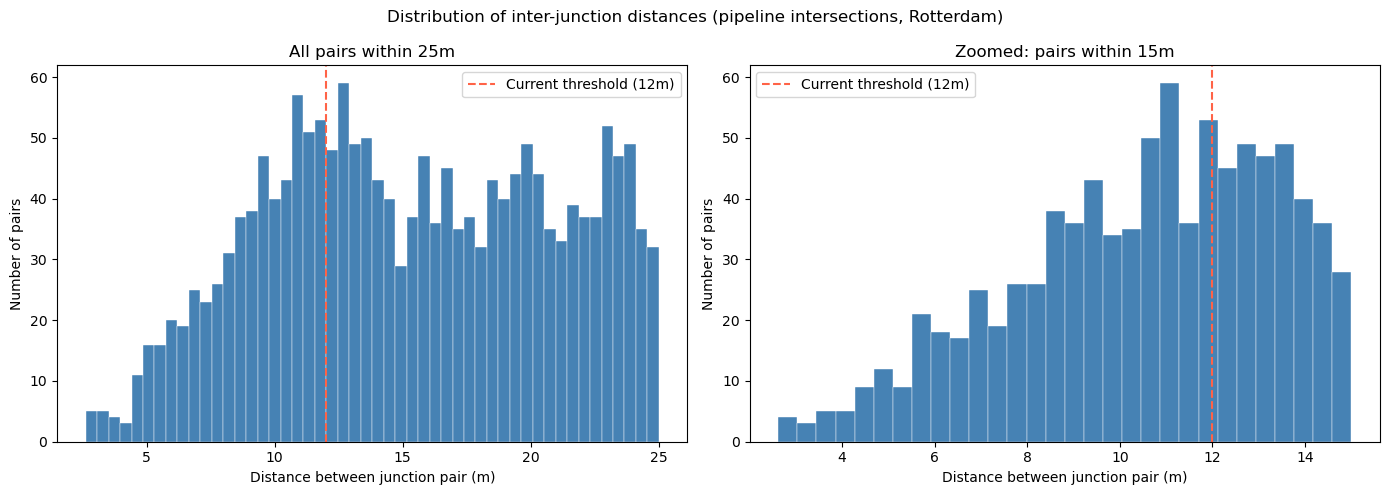

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full range up to SEARCH_RADIUS — gives overall shape
ax = axes[0]
ax.hist(pairs_df["distance"], bins=50, color="steelblue", edgecolor="white", linewidth=0.3)
ax.axvline(BAYONET_THRESHOLD, color="tomato", linewidth=1.5, linestyle="--",
           label=f"Current threshold ({BAYONET_THRESHOLD}m)")
ax.set_xlabel("Distance between junction pair (m)")
ax.set_ylabel("Number of pairs")
ax.set_title(f"All pairs within {SEARCH_RADIUS}m")
ax.legend()

# Right: zoomed into 0–15m — where the bayonet artefacts live
ax = axes[1]
zoom = pairs_df[pairs_df["distance"] <= 15]
ax.hist(zoom["distance"], bins=30, color="steelblue", edgecolor="white", linewidth=0.3)
ax.axvline(BAYONET_THRESHOLD, color="tomato", linewidth=1.5, linestyle="--",
           label=f"Current threshold ({BAYONET_THRESHOLD}m)")
ax.set_xlabel("Distance between junction pair (m)")
ax.set_ylabel("Number of pairs")
ax.set_title("Zoomed: pairs within 15m")
ax.legend()

plt.suptitle("Distribution of inter-junction distances (pipeline intersections, Rotterdam)",
             fontsize=12)
plt.tight_layout()
plt.show()

## 4. Cumulative merge count curve

Shows how many junction pairs would be merged as the threshold increases.
A steep section = many artefacts at that distance; a flat section = a natural gap.
The ideal threshold sits just after a steep section and before the next one.

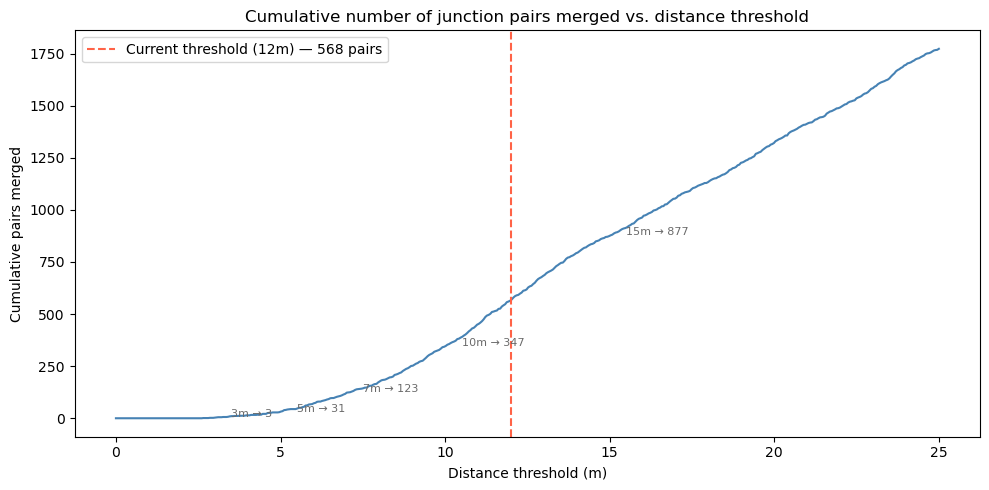

In [14]:
# Compute cumulative count of merged pairs for each distance step
thresholds = np.linspace(0, SEARCH_RADIUS, 500)
cumulative  = [(pairs_df["distance"] <= t).sum() for t in thresholds]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(thresholds, cumulative, color="steelblue", linewidth=1.5)
ax.axvline(BAYONET_THRESHOLD, color="tomato", linewidth=1.5, linestyle="--",
           label=f"Current threshold ({BAYONET_THRESHOLD}m) — "
                 f"{(pairs_df['distance'] <= BAYONET_THRESHOLD).sum()} pairs")

# Annotate a few candidate thresholds for easy reading
for t in [3, 5, 7, 10, 15]:
    n = (pairs_df["distance"] <= t).sum()
    ax.annotate(f"{t}m → {n}",
                xy=(t, n), xytext=(t + 0.5, n + 1),
                fontsize=8, color="dimgray")

ax.set_xlabel("Distance threshold (m)")
ax.set_ylabel("Cumulative pairs merged")
ax.set_title("Cumulative number of junction pairs merged vs. distance threshold")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Threshold sensitivity table

Quick lookup: for each candidate threshold, how many pairs are merged and
what is the marginal gain relative to the previous step?

In [15]:
# Build a summary table for a range of candidate thresholds
candidate_thresholds = [1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20]

rows = []
prev_count = 0
for t in candidate_thresholds:
    count    = int((pairs_df["distance"] <= t).sum())
    marginal = count - prev_count  # new pairs added compared to the previous threshold
    rows.append({"threshold_m": t, "pairs_merged": count, "marginal_gain": marginal})
    prev_count = count

sensitivity = pd.DataFrame(rows)
sensitivity["current"] = sensitivity["threshold_m"].apply(
    lambda t: "<-- current" if t == BAYONET_THRESHOLD else ""
)

print(sensitivity.to_string(index=False))

 threshold_m  pairs_merged  marginal_gain     current
           1             0              0            
           2             0              0            
           3             3              3            
           4            14             11            
           5            31             17            
           6            72             41            
           7           123             51            
           8           174             51            
          10           347            173            
          12           568            221 <-- current
          15           877            309            
          20          1323            446            


## 6. Visual spot-check — 4 pairs near the current threshold

For each of the 4 pairs closest to `BAYONET_THRESHOLD`, draw a zoomed map showing:
- The two junctions (red dots)
- The surrounding road network
- The distance between them

This lets you visually judge whether the threshold is set correctly:
- If the pairs look like genuine artefacts (two dots on top of the same crossing) → threshold is OK or could go slightly higher
- If the pairs look like genuinely distinct intersections → threshold is too high

In [16]:
# Select 4 pairs whose distance is closest to the current threshold.
# We sort by |distance - threshold| to get the most informative edge cases.
pairs_df["dist_to_threshold"] = (pairs_df["distance"] - BAYONET_THRESHOLD).abs()
spot_check = pairs_df.nsmallest(4, "dist_to_threshold").reset_index(drop=True)

print("4 pairs closest to the threshold:")
print(spot_check[["jte_a", "jte_b", "distance"]].to_string(index=False))

4 pairs closest to the threshold:
    jte_a     jte_b  distance
182273133 182273134 12.002645
189274124 189274036 11.996818
179276019 179276012 11.991649
182273128 182273129 12.011527


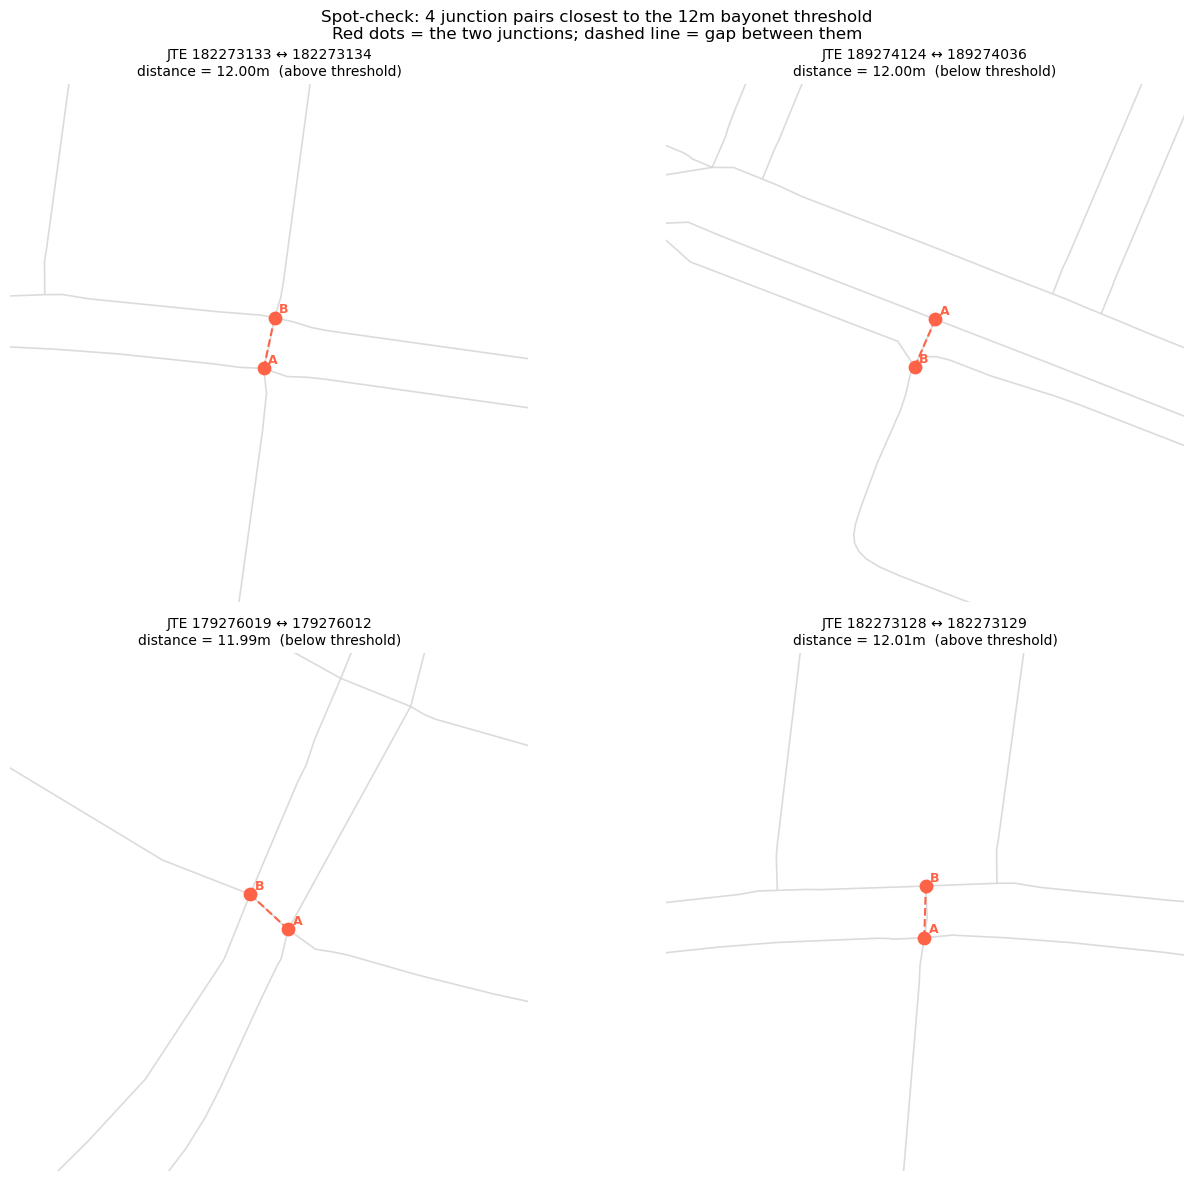

In [17]:
ZOOM_RADIUS = 60  # metres around the pair midpoint for each panel

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for ax, (_, row) in zip(axes.flat, spot_check.iterrows()):

    # Cast to int — DataFrame stores index columns as float which breaks numpy indexing
    pt_a = inter_coords[int(row["idx_a"])]
    pt_b = inter_coords[int(row["idx_b"])]

    # Centre the view on the midpoint of the pair
    mid_x = (pt_a[0] + pt_b[0]) / 2
    mid_y = (pt_a[1] + pt_b[1]) / 2

    # Clip road network to the local zoom window
    from shapely.geometry import Point as ShapelyPoint, box
    zoom_box   = box(mid_x - ZOOM_RADIUS, mid_y - ZOOM_RADIUS,
                     mid_x + ZOOM_RADIUS, mid_y + ZOOM_RADIUS)
    local_wvk  = wegvakken[wegvakken.geometry.intersects(zoom_box)]

    # Background road network
    if not local_wvk.empty:
        local_wvk.plot(ax=ax, color="lightgray", linewidth=1.2, alpha=0.8)

    # The two junction points — red so they stand out
    for pt, label in [(pt_a, "A"), (pt_b, "B")]:
        ax.scatter(*pt, color="tomato", s=80, zorder=5)
        ax.annotate(label, xy=pt, xytext=(pt[0] + 1, pt[1] + 1),
                    fontsize=9, color="tomato", fontweight="bold")

    # Line connecting the two junctions to make the gap visible
    ax.plot([pt_a[0], pt_b[0]], [pt_a[1], pt_b[1]],
            color="tomato", linewidth=1.5, linestyle="--", zorder=4)

    ax.set_xlim(mid_x - ZOOM_RADIUS, mid_x + ZOOM_RADIUS)
    ax.set_ylim(mid_y - ZOOM_RADIUS, mid_y + ZOOM_RADIUS)
    ax.set_title(
        f"JTE {int(row['jte_a'])} ↔ {int(row['jte_b'])}\n"
        f"distance = {row['distance']:.2f}m  "
        f"({'above' if row['distance'] > BAYONET_THRESHOLD else 'below'} threshold)",
        fontsize=10
    )
    ax.set_axis_off()

plt.suptitle(
    f"Spot-check: 4 junction pairs closest to the {BAYONET_THRESHOLD}m bayonet threshold\n"
    f"Red dots = the two junctions; dashed line = gap between them",
    fontsize=12
)
plt.tight_layout()
plt.show()

## 7. Nearest-neighbour distance per junction

For each junction, what is the distance to its closest neighbour?
This complements the pair distribution: if many junctions have a nearest neighbour
very close by (< threshold), there are likely more artefacts to catch.

Nearest-neighbour distance summary (metres):
count    5846.00
mean       38.96
std        31.83
min         2.62
25%        15.73
50%        32.43
75%        55.44
max       492.20

Junctions with nearest neighbour within  5m: 60
Junctions with nearest neighbour within 10m: 625
Junctions with nearest neighbour within 20m: 1,936


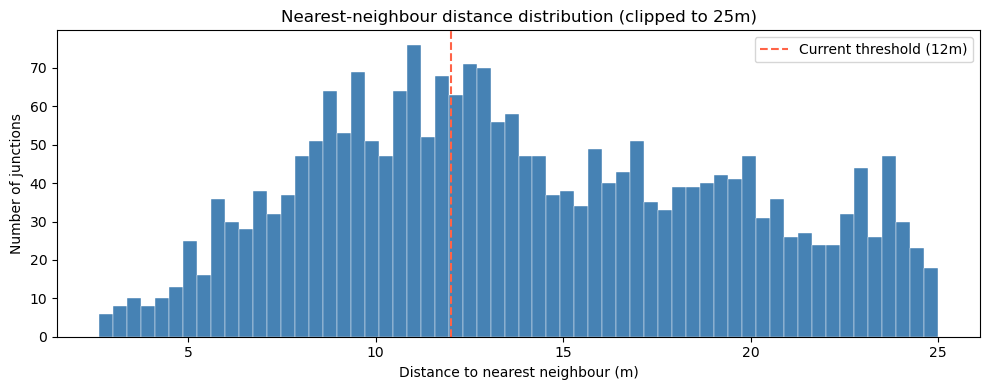

In [18]:
# Query 2 nearest neighbours per point (first is the point itself at distance 0)
nn_dists, _ = tree.query(inter_coords, k=2)
nn_dists    = nn_dists[:, 1]  # drop self (distance 0), keep nearest other junction

print("Nearest-neighbour distance summary (metres):")
print(pd.Series(nn_dists).describe().round(2).to_string())
print()
print(f"Junctions with nearest neighbour within  5m: {(nn_dists <=  5).sum():,}")
print(f"Junctions with nearest neighbour within 10m: {(nn_dists <= 10).sum():,}")
print(f"Junctions with nearest neighbour within 20m: {(nn_dists <= 20).sum():,}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(nn_dists[nn_dists <= SEARCH_RADIUS], bins=60,
        color="steelblue", edgecolor="white", linewidth=0.3)
ax.axvline(BAYONET_THRESHOLD, color="tomato", linewidth=1.5, linestyle="--",
           label=f"Current threshold ({BAYONET_THRESHOLD}m)")
ax.set_xlabel("Distance to nearest neighbour (m)")
ax.set_ylabel("Number of junctions")
ax.set_title(f"Nearest-neighbour distance distribution (clipped to {SEARCH_RADIUS}m)")
ax.legend()
plt.tight_layout()
plt.show()